In [60]:
import numpy as np

import statsmodels.formula.api as smf
import utils.database as db
import utils.model_evaluation as me

# Evaluating bias under model with higher explanatory power

Prior findings showed correlations between racial and political characteristics of a county and the amount of Paycheck Protection Program funds received, but with [relatively low explanatory power](project_regression_analysis.ipynb) (Adj. R^2 = 0.235). 

The goal of this continued research is to see whether these trends persist after adding further economic controls. Specifically, whether county-level industry composition has an impact on distribution of PPP funds. This is an important control as customer-facing industries like restaurants and entertainment were suddenly and immediately shut down in March 2020. Concentration of these customer-facing industries, in particular, are likely an important control for racial and political characteristics (measured as Republican vote share). 

In [61]:
query = """
    SELECT * EXCLUDE (ppp_loan_amount, total_annual_wages)
    FROM gold.wage_adjusted_ppp_target
"""
df = db.query_df(query)

df_clean = df.dropna()
assert len(df) == len(df_clean), 'Design matrix has missing values to remove'
del df_clean
df.head()

,county,state,urbanicity,yoy_job_change_pct,wage_adjusted_ppp_loan_amount,white_pop_share,black_pop_share,asian_pop_share,native_pop_share,hispanic_share,...,manufacturing_wage_share,mining_quarrying_and_oil_and_gas_extraction_wage_share,other_services_except_public_administration_wage_share,professional_and_technical_services_wage_share,real_estate_and_rental_and_leasing_wage_share,retail_trade_wage_share,transportation_and_warehousing_wage_share,unclassified_wage_share,utilities_wage_share,wholesale_trade_wage_share
0,Edwards County,Texas,rural,0.290141,0.109922,0.945652,0.011905,0.007246,0.023810,0.553313,...,0.000000,0.000000,0.013104,0.000000,0.000000,0.119076,0.000000,0.002098,0.000000,0.000000
1,Hall County,Texas,rural,-0.048263,0.244926,0.871120,0.091093,0.004723,0.016194,0.351215,...,0.052279,0.000000,0.052180,0.000000,0.000000,0.197200,0.000000,0.001955,0.000000,0.027006
2,Hardin County,Texas,urban,-0.012079,0.170764,0.915211,0.056109,0.007430,0.006614,0.059738,...,0.105082,0.041900,0.047770,0.057026,0.005361,0.145277,0.025373,0.001242,0.005333,0.027951
3,Smith County,Texas,urban,0.017729,0.123149,0.777548,0.178070,0.016485,0.009525,0.200841,...,0.079799,0.047054,0.022203,0.079743,0.013934,0.098223,0.054516,0.000308,0.006814,0.068501
4,Ward County,Texas,suburban,0.099056,0.113314,0.902234,0.052925,0.005918,0.016836,0.551592,...,0.036694,0.533090,0.012463,0.026225,0.045060,0.041536,0.081697,0.000018,0.011789,0.062882


## Evaluate correlations of numerical variables

Exclude all location quotient information for direct covariance with wage share. Keep wage share to prefer trends in local economic makeup, rather than relation to national economy indicated by loc quotient. 

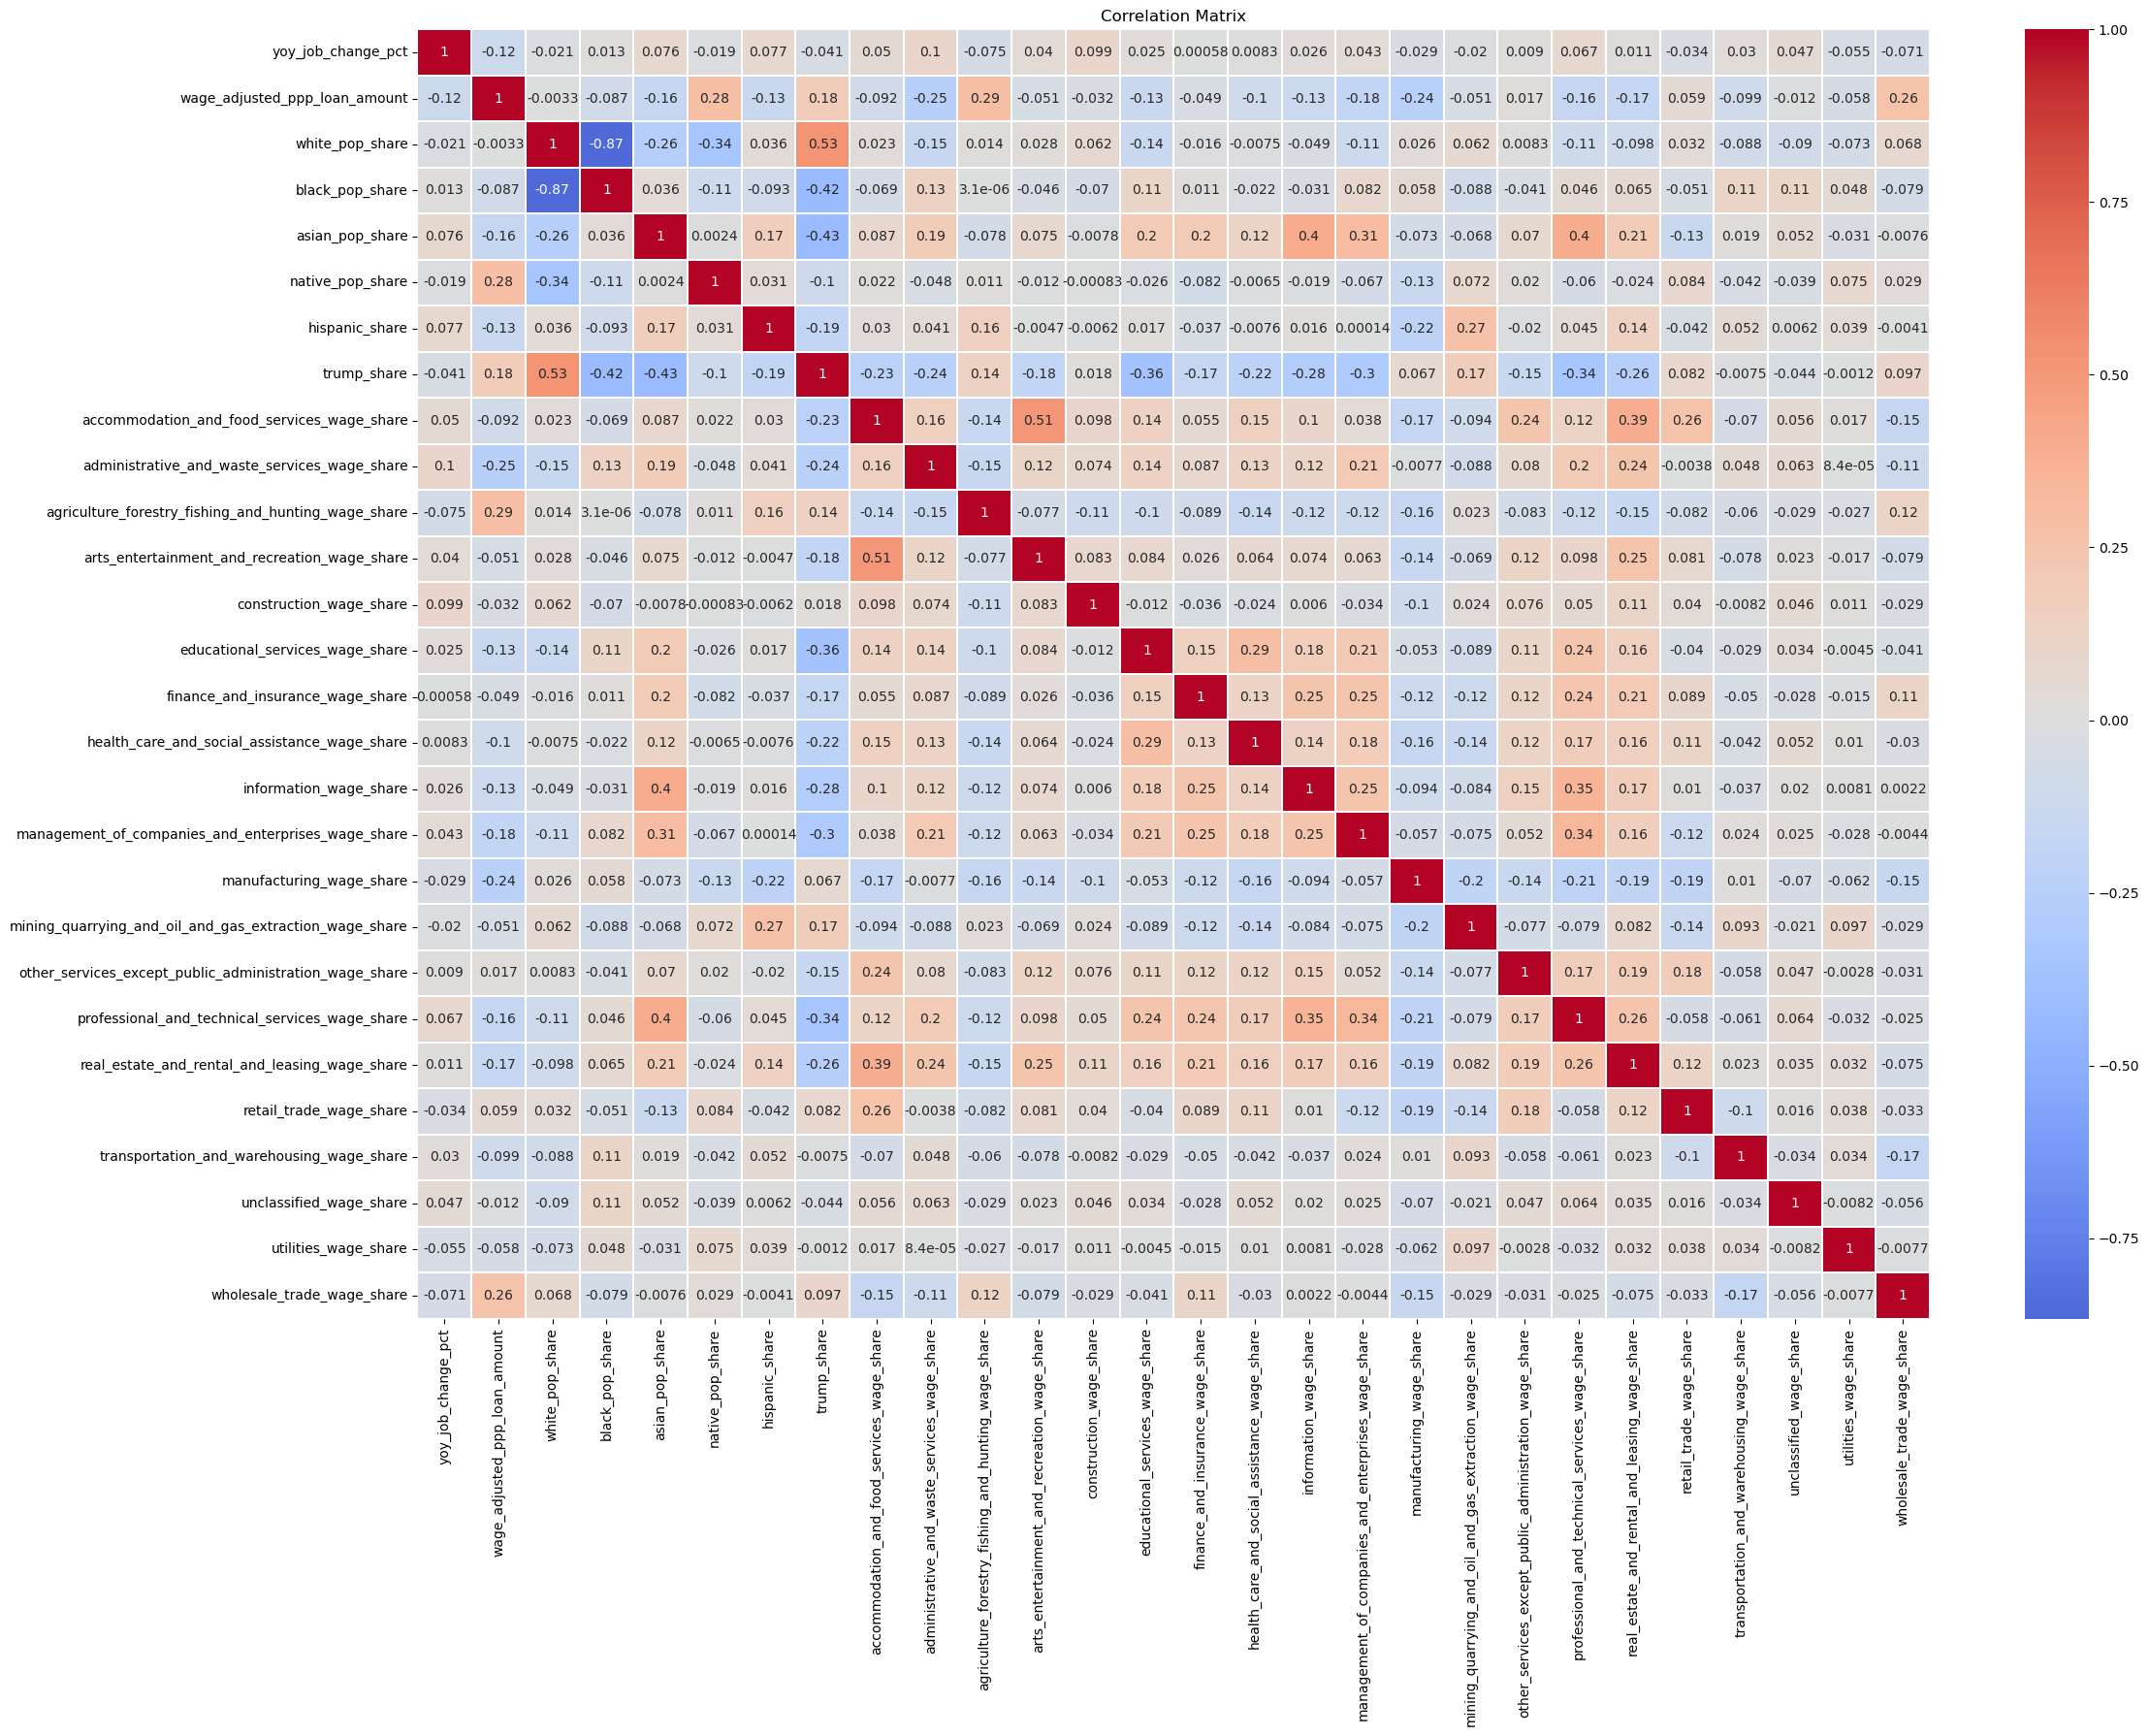

In [62]:
fig_size = (24, 18)
me.plot_correlation_matrix(data=df, fig_size=fig_size, annot=True)

## Evaluate multi-collinearity for regression on all features

Evaluate regression against full model. 

In [63]:
target = 'wage_adjusted_ppp_loan_amount'

base_model_spec = {
    'target': target,
    # 'target_transform': 'log',
    'data': df,
    'exclusion_set': None,
    'cat_var_set': {"C(urbanicity, Treatment(reference='urban'))"}
}

base_model_formula = me.generate_formula_string(**base_model_spec)
base_model = smf.ols(base_model_formula, data=df).fit()

display(base_model.summary())
me.evaluate_vifs(base_model)

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                 
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   R-squared:                       0.398
Model:                                       OLS   Adj. R-squared:                  0.392
Method:                            Least Squares   F-statistic:                     69.94
Date:                           Fri, 25 Jul 2025   Prob (F-statistic):          1.27e-311
Time:                                   10:01:41   Log-Likelihood:                 2334.2
No. Observations:                           3102   AIC:                            -4608.
Df Residuals:                               3072   BIC:                            -4427.
Df Model:                                     29                                         
Covariance Type:                       nonrobust                                         
===========================================================================================================================
                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                  -0.6105      0.177     -3.442      0.001      -0.958      -0.263
C(urbanicity, Treatment(reference='urban'))[T.rural]        0.0809      0.007     11.297      0.000       0.067       0.095
C(urbanicity, Treatment(reference='urban'))[T.suburban]    -0.0022      0.005     -0.426      0.670      -0.013       0.008
accommodation_and_food_services_wage_share                 -0.0038      0.062     -0.061      0.951      -0.125       0.117
administrative_and_waste_services_wage_share               -0.4235      0.073     -5.828      0.000      -0.566      -0.281
agriculture_forestry_fishing_and_hunting_wage_share         0.3899      0.037     10.498      0.000       0.317       0.463
arts_entertainment_and_recreation_wage_share               -0.1215      0.151     -0.804      0.422      -0.418       0.175
asian_pop_share                                             0.8443      0.235      3.587      0.000       0.383       1.306
black_pop_share                                             0.8142      0.179      4.546      0.000       0.463       1.165
construction_wage_share                                     0.0084      0.037      0.229      0.819      -0.063       0.080
educational_services_wage_share                            -0.1623      0.151     -1.074      0.283      -0.459       0.134
finance_and_insurance_wage_share                            0.0974      0.063      1.542      0.123      -0.026       0.221
health_care_and_social_assistance_wage_share               -0.0565      0.022     -2.519      0.012      -0.100      -0.013
hispanic_share                                             -0.1371      0.017     -7.900      0.000      -0.171      -0.103
information_wage_share                                     -0.2642      0.141     -1.869      0.062      -0.541       0.013
management_of_companies_and_enterprises_wage_share         -0.3326      0.103     -3.229      0.001      -0.535      -0.131
manufacturing_wage_share                                   -0.1865      0.017    -11.126      0.000      -0.219      -0.154
mining_quarrying_and_oil_and_gas_extraction_wage_share     -0.1823      0.030     -6.158      0.000      -0.240      -0.124
native_pop_share                                            1.4000      0.195      7.187      0.000       1.018       1.782
other_services_except_public_administration_wage_share      0.5674      0.135      4.196      0.000       0.302       0.833
professional_and_technical_services_wage_share             -0.1579      0.050     -3.173      0.002      -0.25

,Feature,VIF
0,Intercept,7432.630492
27,white_pop_share,191.817821
8,black_pop_share,159.492073
18,native_pop_share,38.519303
7,asian_pop_share,11.320127
24,trump_share,2.352386
1,"C(urbanicity, Treatment(reference='urban'))[T....",1.937364
3,accommodation_and_food_services_wage_share,1.755221
16,manufacturing_wage_share,1.644695
2,"C(urbanicity, Treatment(reference='urban'))[T....",1.602417


# Address multi-collinearity

Remove specific demographic variables to reduce multi-collinearity in demographic and political variables. Start by removing white share, seeing covariance matrix trend between white population and Trump share and stronger correlation between target and black population share.

Adjustment removes only `white_pop_share` and brings VIFs into acceptable ranges to proceed.  

In [64]:
m_col_model_spec = {
    'target': target,
    'target_transform': 'log',
    'data': df,
    'exclusion_set': {'white_pop_share'},
    'cat_var_set': {"C(urbanicity, Treatment(reference='urban'))"}
}

m_col_formula = me.generate_formula_string(**m_col_model_spec)
m_col_model = smf.ols(m_col_formula, data=df).fit(cov_type='HC3')

me.evaluate_vifs(m_col_model)

,Feature,VIF
0,Intercept,90.255854
24,trump_share,2.350404
1,"C(urbanicity, Treatment(reference='urban'))[T....",1.927146
3,accommodation_and_food_services_wage_share,1.737399
16,manufacturing_wage_share,1.639242
2,"C(urbanicity, Treatment(reference='urban'))[T....",1.599033
8,black_pop_share,1.575033
7,asian_pop_share,1.561497
20,professional_and_technical_services_wage_share,1.546166
21,real_estate_and_rental_and_leasing_wage_share,1.454567


## Multi-collinear adjustment results

Removing white vote share addressed multi-collinearity sufficiently to proceed with control model analysis of demographic trends against industry totals. 

In [56]:
m_col_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      OLS Regression Results                                     
=================================================================================================
Dep. Variable:     np.log(wage_adjusted_ppp_loan_amount)   R-squared:                       0.448
Model:                                               OLS   Adj. R-squared:                  0.443
Method:                                    Least Squares   F-statistic:                     72.64
Date:                                   Fri, 25 Jul 2025   Prob (F-statistic):          3.31e-313
Time:                                           10:00:32   Log-Likelihood:                -1597.0
No. Observations:                                   3102   AIC:                             3252.
Df Residuals:                                       3073   BIC:                             3427.
Df Model:                                             28                                         
Covariance Type:                                     HC3                                         
===========================================================================================================================
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                  -2.1866      0.103    -21.236      0.000      -2.388      -1.985
C(urbanicity, Treatment(reference='urban'))[T.rural]        0.3751      0.034     10.923      0.000       0.308       0.442
C(urbanicity, Treatment(reference='urban'))[T.suburban]     0.0636      0.019      3.349      0.001       0.026       0.101
accommodation_and_food_services_wage_share                  0.1401      0.253      0.554      0.579      -0.355       0.636
administrative_and_waste_services_wage_share               -2.1197      0.287     -7.374      0.000      -2.683      -1.556
agriculture_forestry_fishing_and_hunting_wage_share         1.4917      0.210      7.115      0.000       1.081       1.903
arts_entertainment_and_recreation_wage_share                0.1590      0.712      0.223      0.823      -1.237       1.555
asian_pop_share                                            -1.3160      0.460     -2.861      0.004      -2.217      -0.414
black_pop_share                                             0.0671      0.068      0.992      0.321      -0.065       0.200
construction_wage_share                                     0.7384      0.360      2.051      0.040       0.033       1.444
educational_services_wage_share                            -0.4778      0.416     -1.150      0.250      -1.292       0.337
finance_and_insurance_wage_share                            0.9028      0.270      3.342      0.001       0.373       1.432
health_care_and_social_assistance_wage_share               -0.0813      0.088     -0.921      0.357      -0.254       0.092
hispanic_share                                             -0.5650      0.081     -7.017      0.000      -0.723      -0.407
information_wage_share                                     -0.4178      0.472     -0.885      0.376      -1.343       0.508
management_of_companies_and_enterprises_wage_share         -1.8156      0.342     -5.305      0.000      -2.486      -1.145
manufacturing_wage_share                                   -0.5282      0.096     -5.479      0.000      -0.717      -0.339
mining_quarrying_and_oil_and_gas_extraction_wage_share     -0.7551      0.256     -2.950      0.003      -1.257      -0.253
native_pop_share                                            0.9249      0.238      3.893      0.000       0.459       1.391
other_services_except_public_administration_wage_share      1.9788      0.797      2.484      0.013       0.418       3.540
professional_and_techn

bp_stat: 411.4942180915269 | bp_pvalue: 8.962306259535896e-70


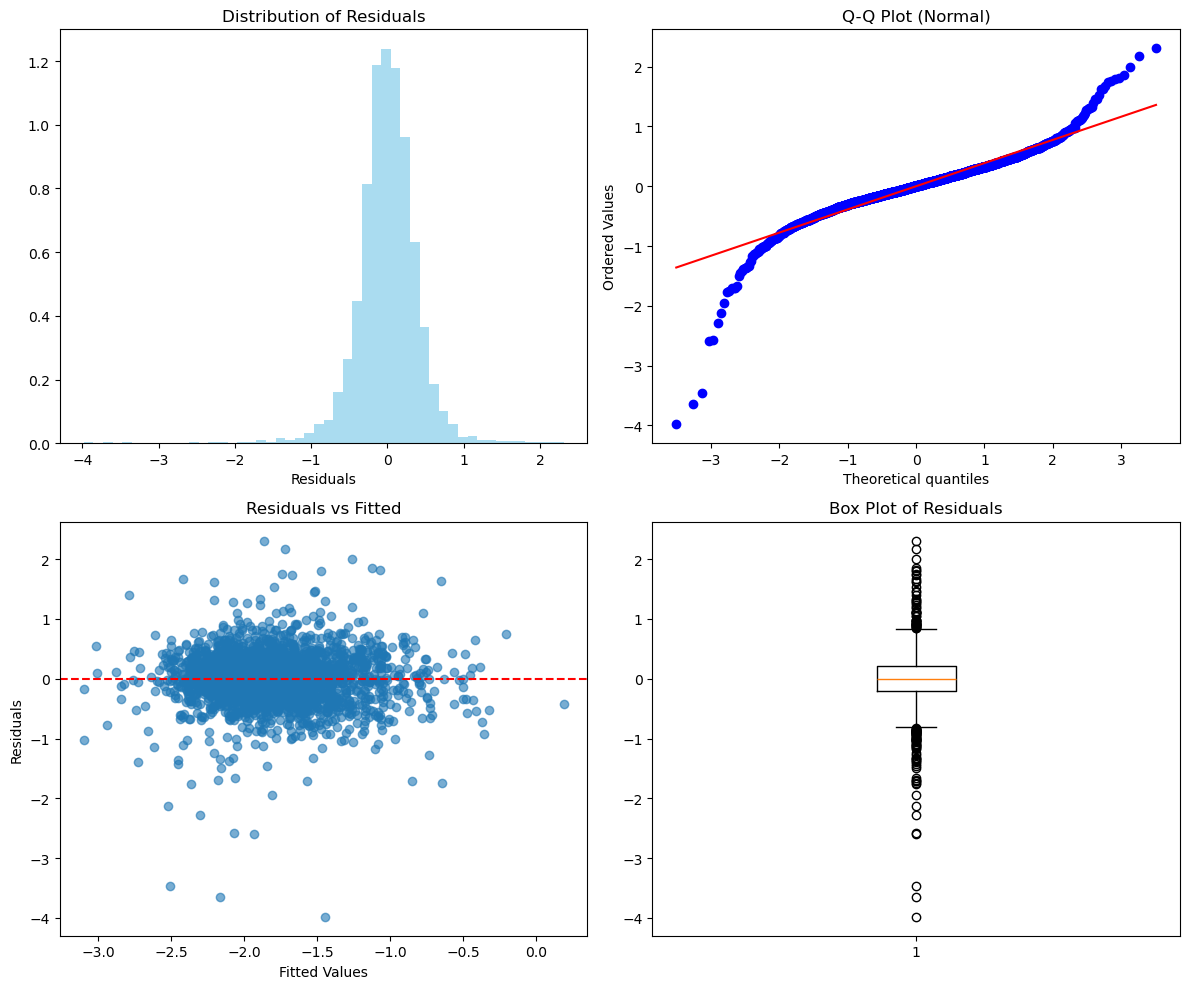

In [57]:
me.test_model_assumptions(m_col_model)

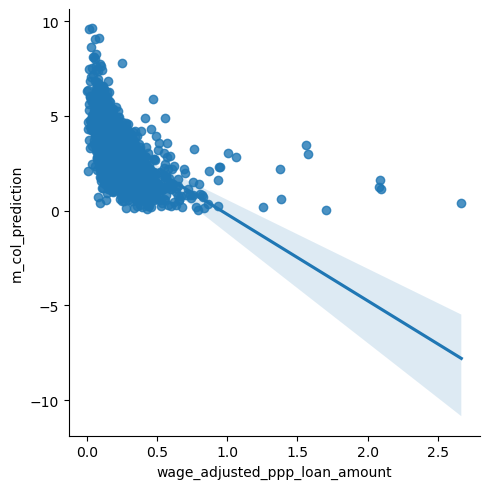

In [58]:
import seaborn as sns
df['m_col_prediction'] = np.power(m_col_model.fittedvalues, 2)
g = sns.lmplot(x=f"{target}", y="m_col_prediction", data=df)

## Model shows heteroskedastiacity, violating model assumption

Violates assumption of normally distributed residuals, making coefficients unreliable. Investigating robust standard errors for improvements to p-value assessment, but transformations or feature combinations should also be explored based on heteroskedasticity analysis of individual features.

Heteroscedacity evaluation for accommodation_and_food_services_wage_share
bp_stat: 6.179513985619006 | bp_pvalue: 0.01292377709516121


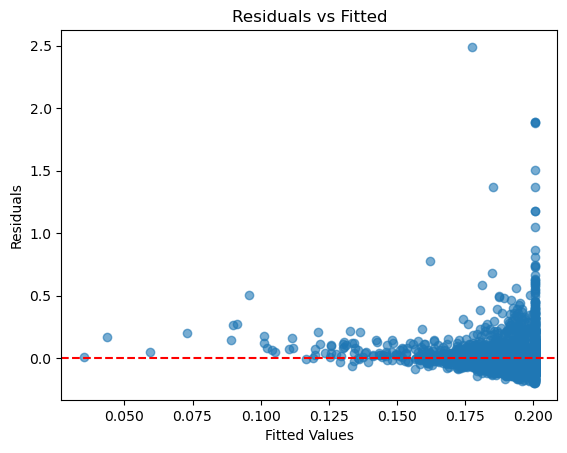

Heteroscedacity evaluation for administrative_and_waste_services_wage_share
bp_stat: 13.821176722570847 | bp_pvalue: 0.00020105728450487252


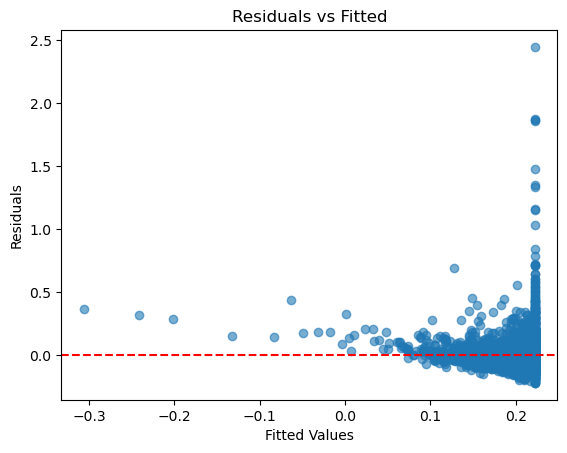

Heteroscedacity evaluation for agriculture_forestry_fishing_and_hunting_wage_share
bp_stat: 39.78430997663009 | bp_pvalue: 2.8361433864261395e-10


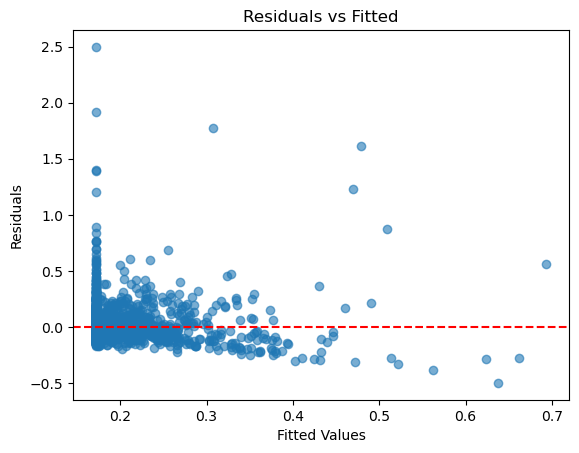

Heteroscedacity evaluation for arts_entertainment_and_recreation_wage_share
bp_stat: 3.9131727651108315 | bp_pvalue: 0.04790906962344702


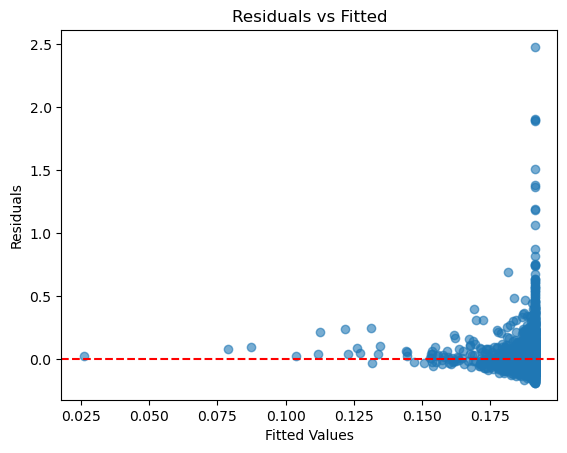

Heteroscedacity evaluation for asian_pop_share
bp_stat: 2.47841012712686 | bp_pvalue: 0.11541887032017242


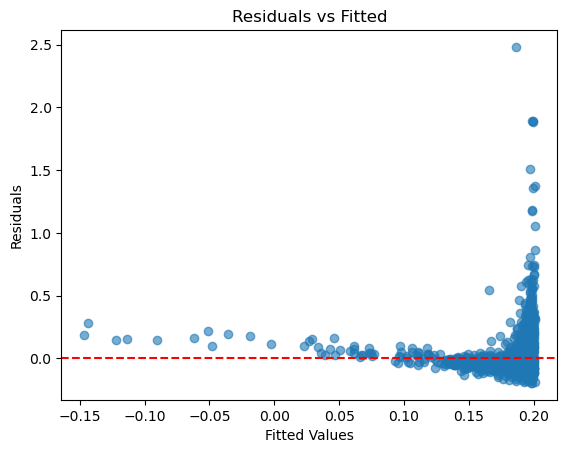

Heteroscedacity evaluation for black_pop_share
bp_stat: 5.412975822972697 | bp_pvalue: 0.0199876148438472


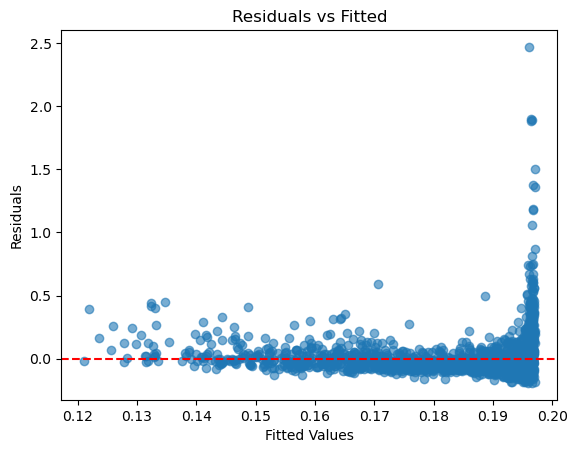

Heteroscedacity evaluation for construction_wage_share
bp_stat: 16.035244105463896 | bp_pvalue: 6.21742721362431e-05


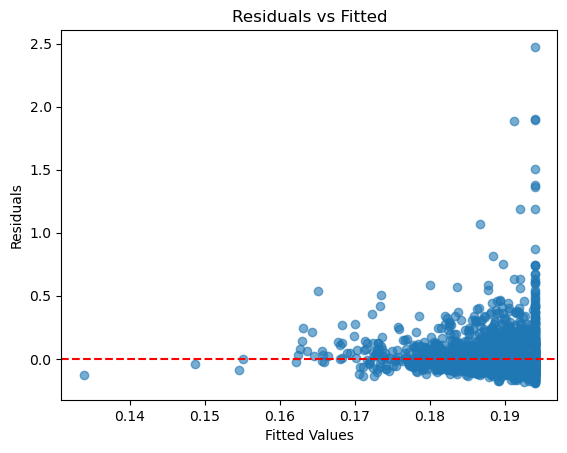

Heteroscedacity evaluation for educational_services_wage_share
bp_stat: 3.8890840089785104 | bp_pvalue: 0.0486009237596074


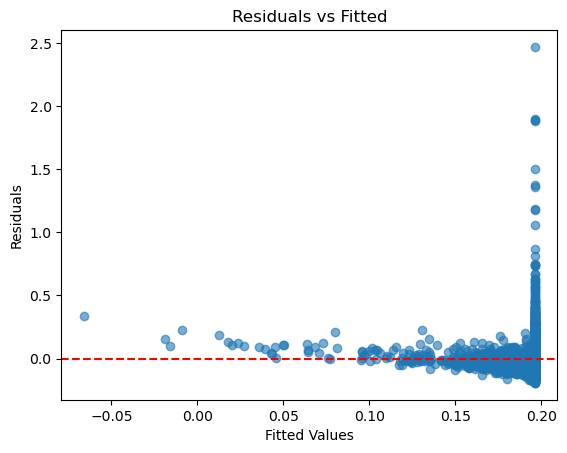

Heteroscedacity evaluation for finance_and_insurance_wage_share
bp_stat: 11.541640736839287 | bp_pvalue: 0.000680545540962739


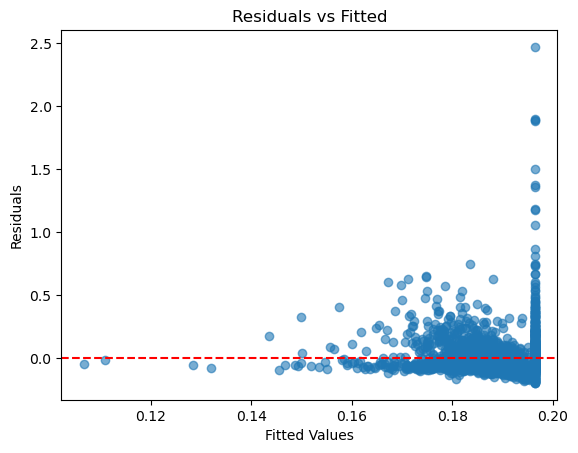

Heteroscedacity evaluation for health_care_and_social_assistance_wage_share
bp_stat: 3.1627551502811544 | bp_pvalue: 0.0753359406205745


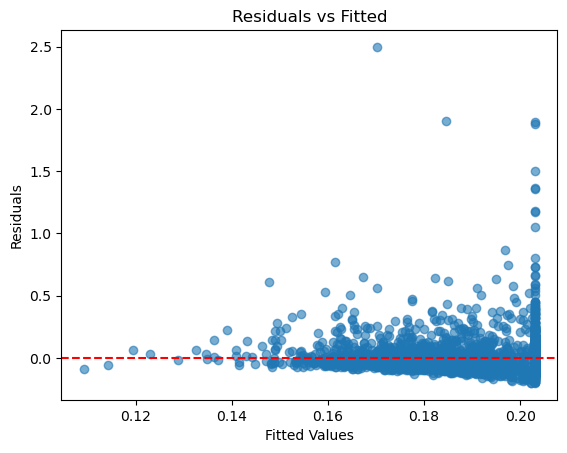

Heteroscedacity evaluation for hispanic_share
bp_stat: 4.820310282216694 | bp_pvalue: 0.02812628175144022


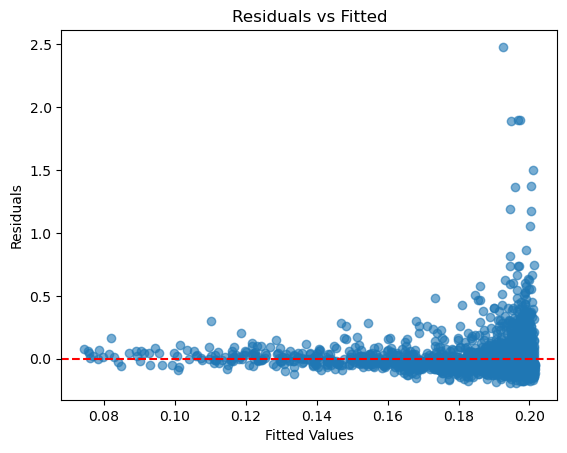

Heteroscedacity evaluation for information_wage_share
bp_stat: 8.517771334907902 | bp_pvalue: 0.003516949277379516


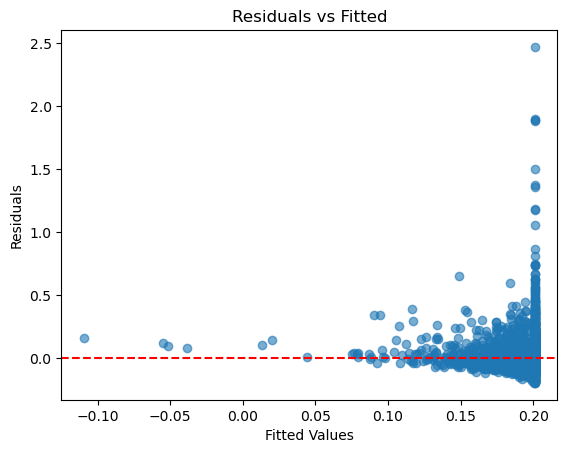

Heteroscedacity evaluation for management_of_companies_and_enterprises_wage_share
bp_stat: 5.235718213509555 | bp_pvalue: 0.02212767055646717


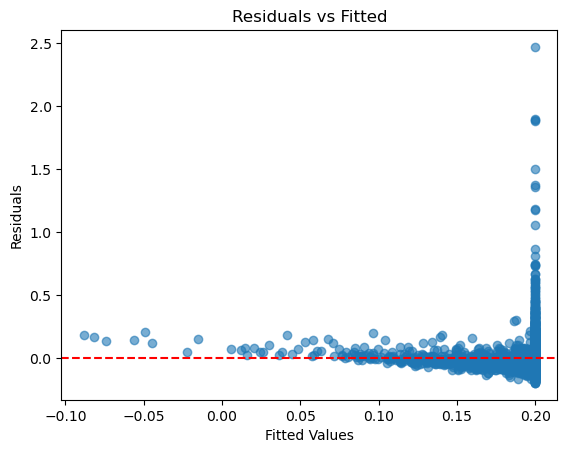

Heteroscedacity evaluation for manufacturing_wage_share
bp_stat: 31.374349793088797 | bp_pvalue: 2.127733817664266e-08


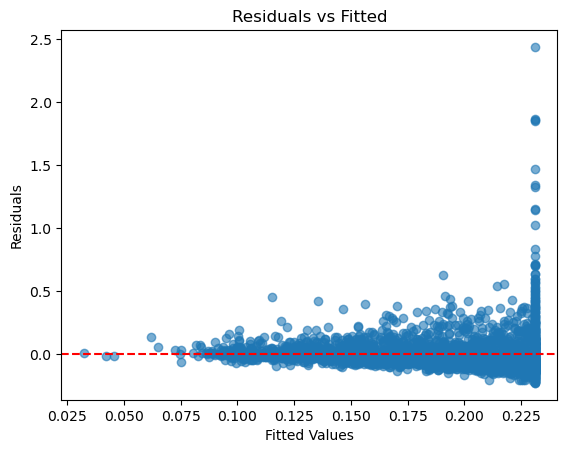

Heteroscedacity evaluation for mining_quarrying_and_oil_and_gas_extraction_wage_share
bp_stat: 1.451297892776962 | bp_pvalue: 0.2283198087795572


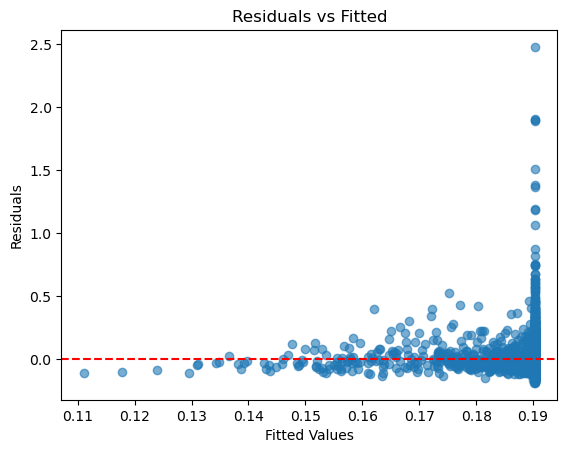

Heteroscedacity evaluation for native_pop_share
bp_stat: 178.05794793479475 | bp_pvalue: 1.2866532642728668e-40


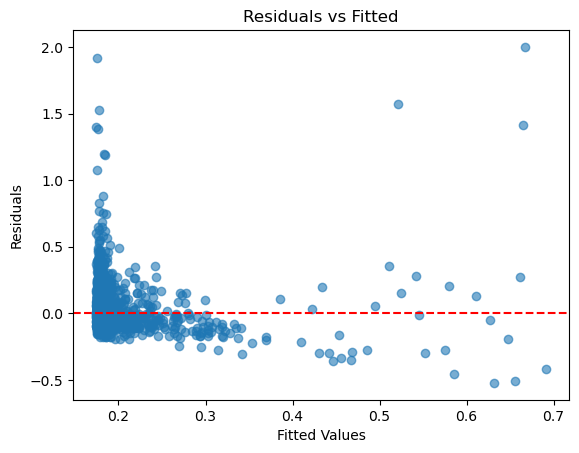

Heteroscedacity evaluation for other_services_except_public_administration_wage_share
bp_stat: 20.862837134761968 | bp_pvalue: 4.933744947145083e-06


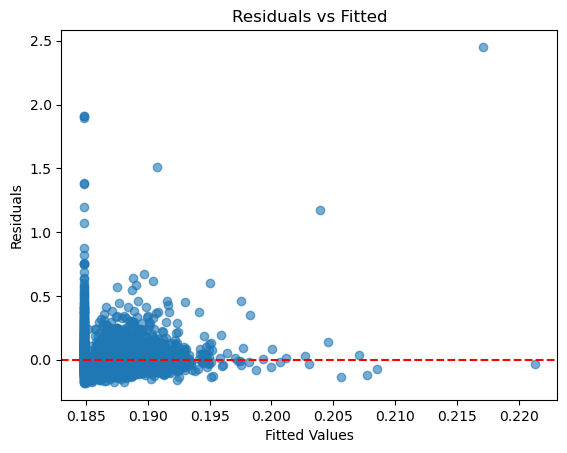

Heteroscedacity evaluation for professional_and_technical_services_wage_share
bp_stat: 11.602331652794517 | bp_pvalue: 0.0006586918475427005


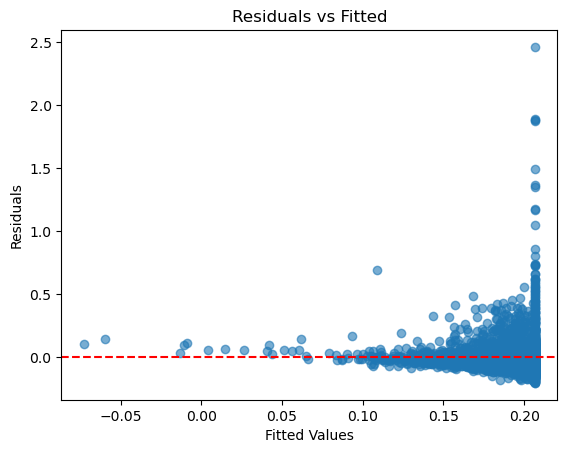

Heteroscedacity evaluation for real_estate_and_rental_and_leasing_wage_share
bp_stat: 13.025728612121608 | bp_pvalue: 0.00030724051707592366


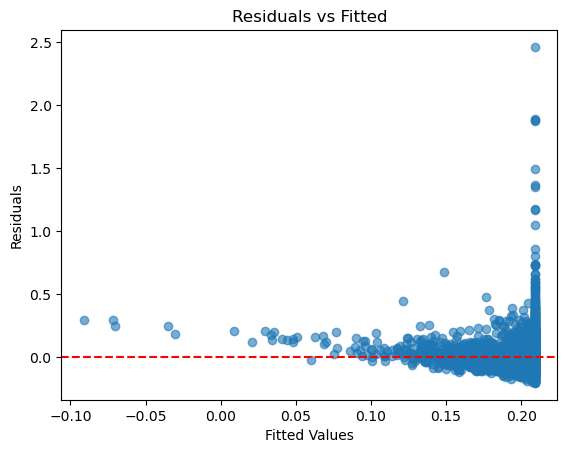

Heteroscedacity evaluation for retail_trade_wage_share
bp_stat: 33.56797281155946 | bp_pvalue: 6.881654983913927e-09


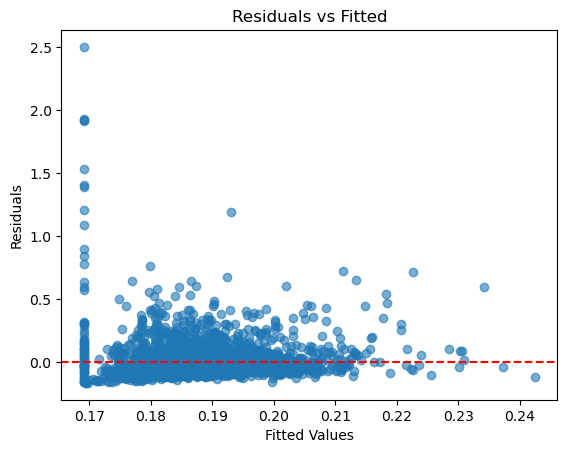

Heteroscedacity evaluation for transportation_and_warehousing_wage_share
bp_stat: 4.588440977577017 | bp_pvalue: 0.03218827977922575


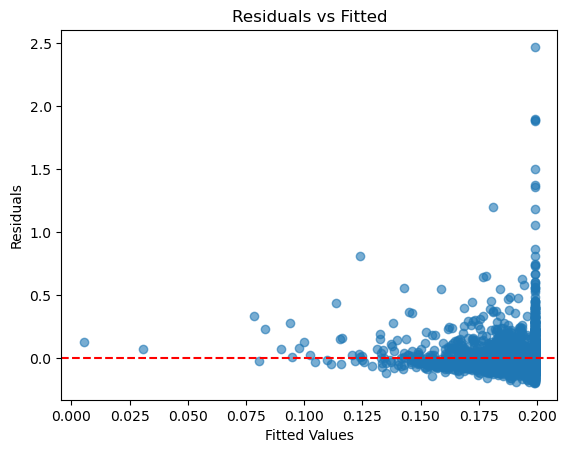

Heteroscedacity evaluation for trump_share
bp_stat: 0.07813589663440501 | bp_pvalue: 0.7798396615854061


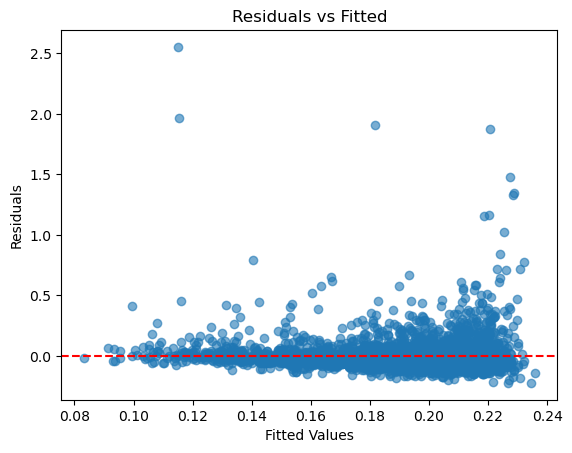

Heteroscedacity evaluation for unclassified_wage_share
bp_stat: 0.25829582751400815 | bp_pvalue: 0.6112933687079094


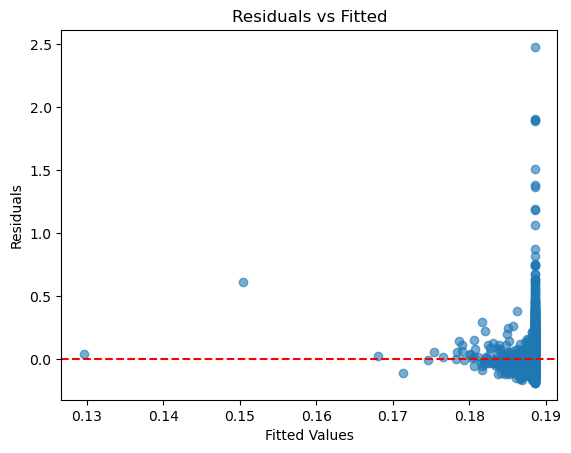

Heteroscedacity evaluation for utilities_wage_share
bp_stat: 2.646017832419332 | bp_pvalue: 0.10380965015179541


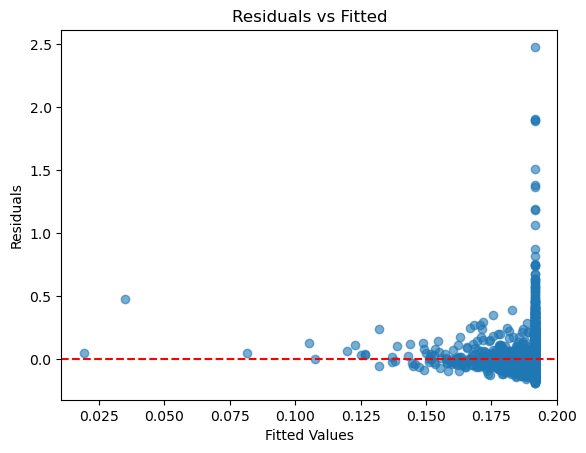

Heteroscedacity evaluation for wholesale_trade_wage_share
bp_stat: 0.2478646964653597 | bp_pvalue: 0.6185826396158107


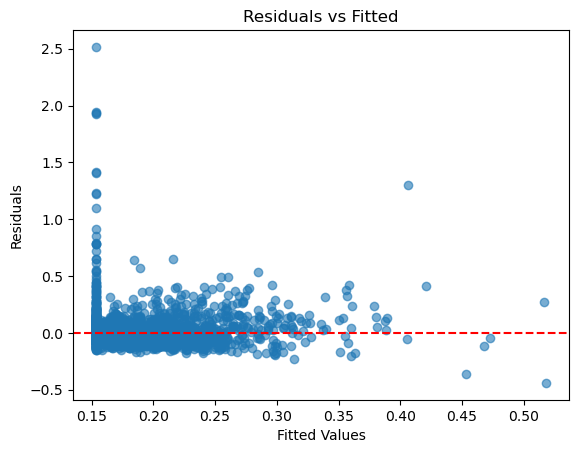

Heteroscedacity evaluation for yoy_job_change_pct
bp_stat: 9.897623839371768 | bp_pvalue: 0.001654923194462532


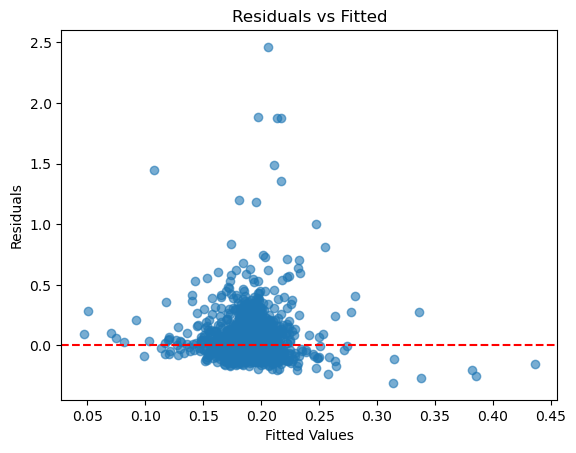

In [47]:
import pandas as pd
from statsmodels.stats.diagnostic import het_breuschpagan
import numpy as np
import matplotlib.pyplot as plt

def plot_residual_v_fitted(model):
    fitted = model.fittedvalues
    residuals = model.resid
    features = model.model.exog
    
    bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, features)
    print(f'bp_stat: {bp_stat} | bp_pvalue: {bp_pvalue}')
    plt.scatter(fitted, residuals, alpha=0.6)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')
    plt.title('Residuals vs Fitted')
    plt.show()
    return bp_stat, bp_pvalue

def isolate_het_residuals(model):
    
    df = model.model.data.frame
    feature_names = model.model.exog_names[1:]
    dep_var = model.model.endog_names
    
    results = []
    for feature in feature_names:
        if not feature.startswith('C(') and feature != target:
            print(f'Heteroskedasticity evaluation for {feature}')
            formula = f'{dep_var} ~ np.arcsinh({feature})'
            test_model = smf.ols(formula, data=df).fit(cov_type='HC3')
            bp_stat, bp_pvalue = plot_residual_v_fitted(test_model)
            results.append({
                'feature': feature,
                'bp_stat': bp_stat,
                'bp_pvalue': bp_pvalue
            })
    return pd.DataFrame(results)

het_results = isolate_het_residuals(m_col_model)

In [30]:
problem_vars = het_results[het_results['bp_pvalue'] <= 0.001]
concern_vars = het_results[(het_results['bp_pvalue'] > 0.001) & (het_results['bp_pvalue'] <= 0.05)]

print('Problems')
display(problem_vars)

print('Concerns')
display(concern_vars)

Problems


,feature,bp_stat,bp_pvalue
0,accommodation_and_food_services_wage_share,61.211541,5.126015e-15
1,administrative_and_waste_services_wage_share,23.390543,1.322270e-06
3,arts_entertainment_and_recreation_wage_share,15.568182,7.958262e-05
6,construction_wage_share,11.427776,7.235423e-04
7,educational_services_wage_share,12.849870,3.375027e-04
8,finance_and_insurance_wage_share,29.230391,6.426329e-08
9,health_care_and_social_assistance_wage_share,42.614038,6.667912e-11
11,information_wage_share,30.129641,4.041073e-08
12,management_of_companies_and_enterprises_wage_s...,20.703246,5.362501e-06
13,manufacturing_wage_share,71.748610,2.444361e-17


Concerns


,feature,bp_stat,bp_pvalue
2,agriculture_forestry_fishing_and_hunting_wage_...,8.551527,0.003452
5,black_pop_share,6.124842,0.013330
20,transportation_and_warehousing_wage_share,4.227894,0.039765
23,utilities_wage_share,10.569227,0.001150
24,wholesale_trade_wage_share,6.829470,0.008967


## Consider combination of variables and remove additional features

Proceed with combining specific industry wage shares similarly affected during the pandemic as a general economic control.

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                 
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   R-squared:                       0.210
Model:                                       OLS   Adj. R-squared:                  0.209
Method:                            Least Squares   F-statistic:                     137.4
Date:                           Fri, 25 Jul 2025   Prob (F-statistic):          1.06e-154
Time:                                   09:34:15   Log-Likelihood:                 1914.2
No. Observations:                           3102   AIC:                            -3814.
Df Residuals:                               3095   BIC:                            -3772.
Df Model:                                      6                                         
Covariance Type:                       nonrobust                                         
===========================================================================================================================
                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                   0.1859      0.017     10.623      0.000       0.152       0.220
C(urbanicity, Treatment(reference='urban'))[T.rural]        0.1470      0.007     20.373      0.000       0.133       0.161
C(urbanicity, Treatment(reference='urban'))[T.suburban]     0.0047      0.006      0.824      0.410      -0.006       0.016
hispanic_share                                             -0.0693      0.017     -3.975      0.000      -0.103      -0.035
retail_asin                                                 0.0121      0.029      0.418      0.676      -0.045       0.069
sqrt_asian_pop_share                                       -0.2730      0.045     -6.068      0.000      -0.361      -0.185
trump_share                                                 0.0045      0.018      0.252      0.801      -0.031       0.040
==============================================================================
Omnibus:                     3886.520   Durbin-Watson:                   1.808
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           958544.652
Skew:                           6.561   Prob(JB):                         0.00
Kurtosis:                      88.112   Cond. No.                         27.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

bp_stat: 166.45995310894511 | bp_pvalue: 2.5330573763348583e-33


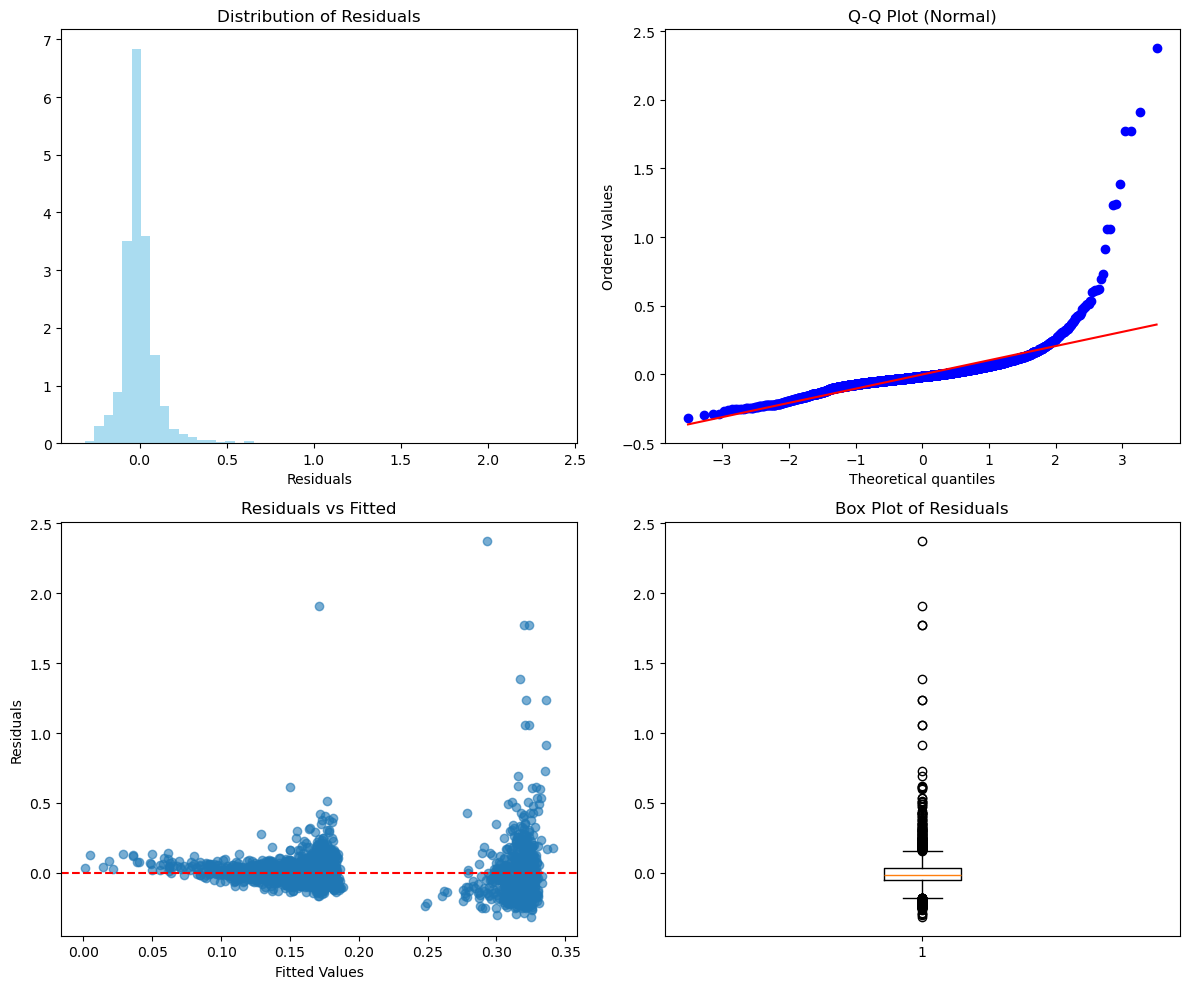

In [42]:
bias_q = """
    SELECT 
        wage_adjusted_ppp_loan_amount,
        ASIN(SQRT(retail_trade_wage_share)) as retail_asin,
        trump_share,
        SQRT(asian_pop_share) AS sqrt_asian_pop_share,
        hispanic_share,
        urbanicity
    FROM gold.wage_adjusted_ppp_target
"""

bias_df = db.query_df(bias_q)

bias_model_spec = {
    'target': target,
    # 'target_transform': 'log',
    'data': bias_df,
    'exclusion_set': {},
    'cat_var_set': {"C(urbanicity, Treatment(reference='urban'))"}
}

bias_formula = me.generate_formula_string(**bias_model_spec)

bias_model = smf.ols(bias_formula, data=bias_df).fit()

display(bias_model.summary())
me.test_model_assumptions(bias_model)

Heteroscedacity evaluation for hispanic_share
bp_stat: 4.820310282218071 | bp_pvalue: 0.028126281751417792


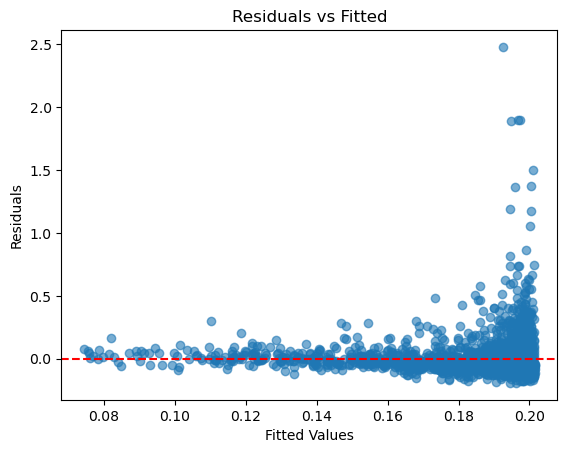

Heteroscedacity evaluation for retail_asin
bp_stat: 110.61449390719 | bp_pvalue: 7.187216020745238e-26


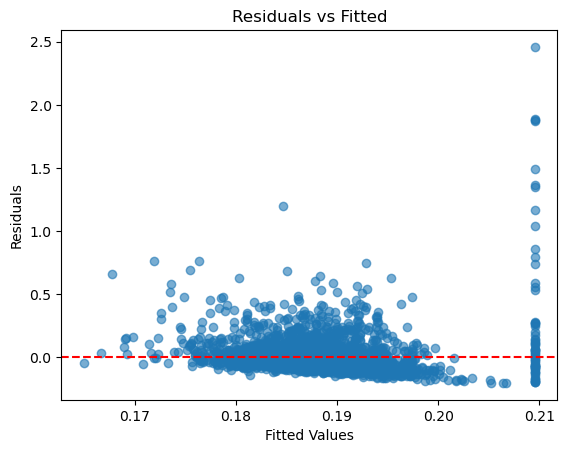

Heteroscedacity evaluation for sqrt_asian_pop_share
bp_stat: 10.444741894217213 | bp_pvalue: 0.0012299909304796593


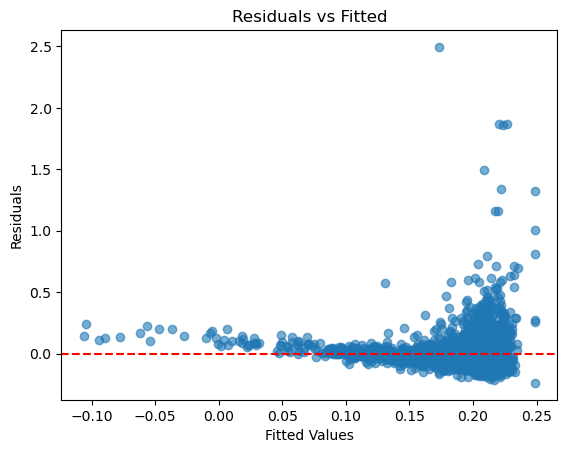

Heteroscedacity evaluation for trump_share
bp_stat: 0.07813589663199427 | bp_pvalue: 0.7798396615887148


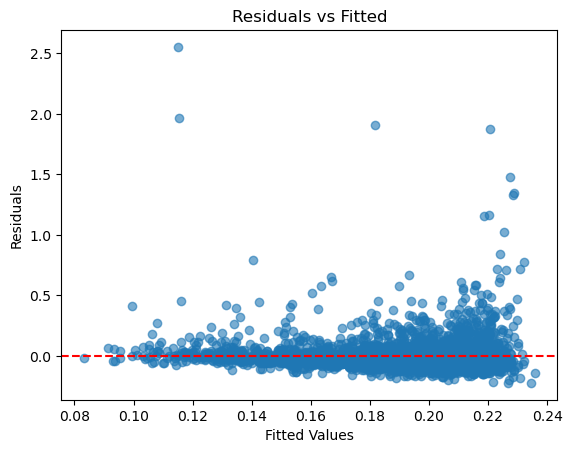

,feature,bp_stat,bp_pvalue
0,hispanic_share,4.820310,2.812628e-02
1,retail_asin,110.614494,7.187216e-26
2,sqrt_asian_pop_share,10.444742,1.229991e-03
3,trump_share,0.078136,7.798397e-01


In [43]:
isolate_het_residuals(bias_model)

In [18]:
for var in no_loc_df.select_dtypes(include=[np.number]).columns:
    
    if var == target:
        continue
        
    print(f'Evaluating bp_stat for: {var}')
    het_model_spec = {
        'target': target,
        'transform': 'log',
        'data': no_loc_df,
        'exclusion_set': {no_loc_df.columns} - {var},
        'cat_var_set': {"C(urbanicity, Treatment(reference='urban'))"}
    }.copy()
    
    het_model_formula = me.generate_formula_string(**het_model_spec)
    het_model = smf.ols(het_model_formula, data=no_loc_df).fit(cov_type='HC3')
    
    me.test_model_assumptions(het_model)

Evaluating bp_stat for: yoy_job_change_pct


TypeError: unhashable type: 'Index'

## Test robust model

Makes heteroskedasticity worse. Return to HC3 or transformations to approach more normal residuals. 

bp_stat: 1521.6722223992135 | bp_pvalue: 1.3025743051499262e-302


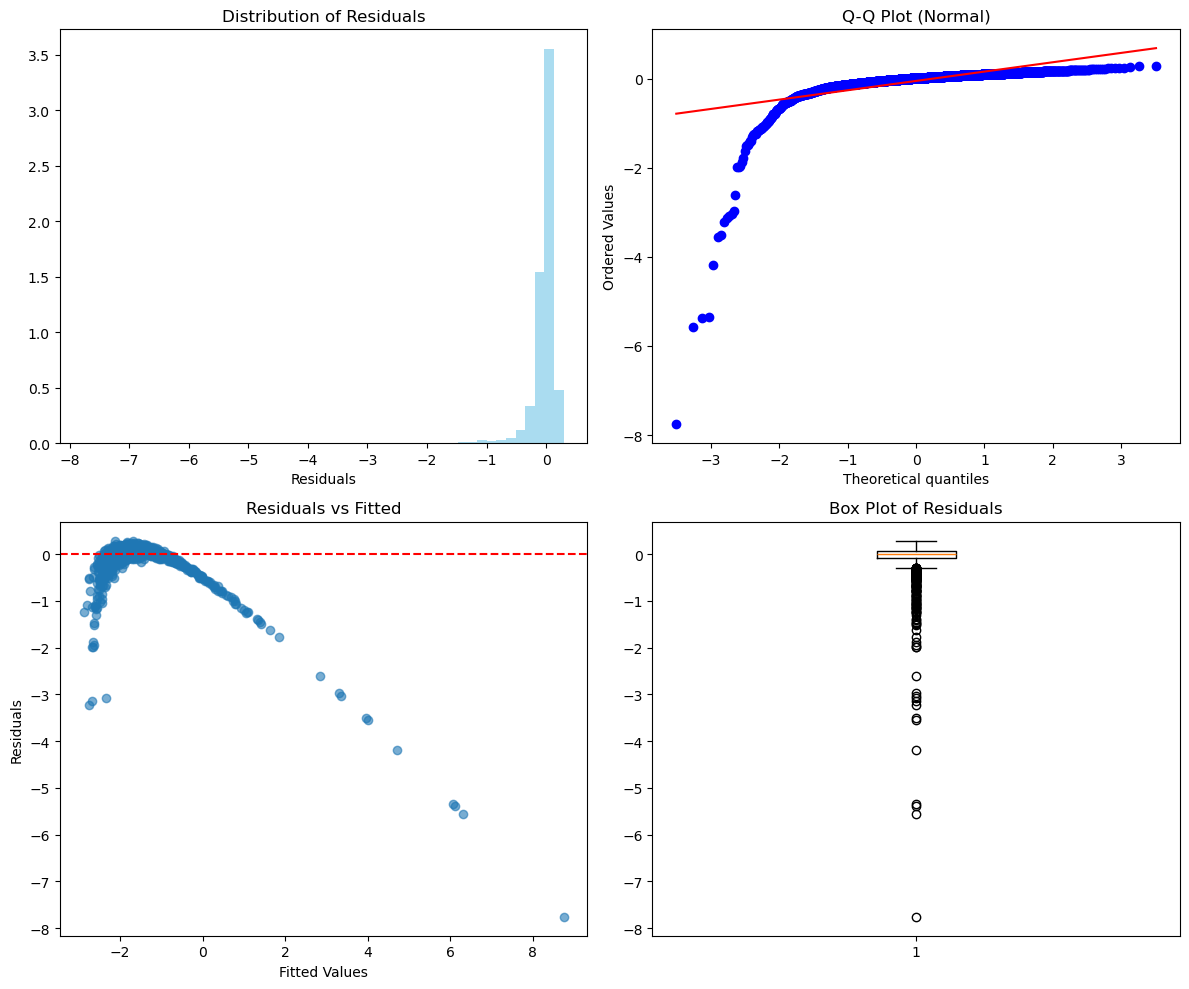

In [45]:
robust_model = smf.rlm(formula=m_col_formula, data=no_loc_df).fit()
robust_model.summary()
me.test_model_assumptions(robust_model)